# 01 — M1: the temporal dataset (what the generator must imitate)

**Goal.** Build the "real" data for this study: for three SimBench
MV feeders, apply the feeder's own full-year 15-min profiles step by step, solve an AC
power flow per step, store the full per-bus state, and gate every step on a physics
self-check. This notebook *reads and audits* the dataset produced by
`gridfm/temporal_data.py` (deterministic — the profiles are the scenario sequence;
no sampling anywhere).

**Feeder split** (decided after probing all candidates): train = **rural0, semiurb0**
(residential/mixed), held out = **comm0** (commercial — its daily *shape* differs, which
is the transfer stressor that matters for a generative model). All three carry
substantial DER; rural0's installed DER (~20 MW) is 2.7× its peak load (7.5 MW), so
reverse power flow is a routine operating condition, not a corner case.

**Conventions inherited from the evidence base** (companion topology study): `-no_sw` grids with
topology via line `in_service` (exact bus↔solver bijection); storage folded into net
demand (none of the three chosen feeders has storage — checked); physics gate
max |S_calc − S_inj| ≤ 1e-3 MVA per step, computed in float64.

**A measured numerical fact** (found during the probe, recorded for M3): the solver's
states satisfy power balance to ~1e-8 MVA in float64, but merely *casting the state to
float32* raises the residual to ~3e-3 MVA. The M3 physics loss will run on float32 GPU
tensors — its achievable floor is that number, not the solver's 1e-8.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "m1"
RES = ROOT / "results" / "m1"
RES.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): categorical fixed order, ink/grid chrome
C = dict(blue="#2a78d6", aqua="#1baf7a", yellow="#eda100", green="#008300",
         violet="#4a3aa7", red="#e34948")
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})
FEEDERS = ["rural0", "semiurb0", "comm0"]
FCOLOR = {"rural0": C["blue"], "semiurb0": C["aqua"], "comm0": C["yellow"]}

D = {}
for f in FEEDERS:
    z = np.load(DATA / f"{f}_year.npz")
    meta = json.loads(str(z["meta"]))
    ref = int(np.argmax(z["static"][:, 5]))           # REF bus row
    D[f] = dict(dyn=z["dyn"], static=z["static"], resid=z["resid_mva"],
                edge_index=z["edge_index"], meta=meta, ref=ref)
    assert meta["gate_pass"], f"{f}: physics gate FAILED — do not train on this"

manifest = pd.DataFrame([{
    "feeder": f, "role": D[f]["meta"]["role"], "buses": D[f]["meta"]["n_bus"],
    "steps": D[f]["meta"]["steps"], "pf_failures": D[f]["meta"]["pf_failures"],
    "resid_max_MVA_f64": D[f]["meta"]["resid_max_mva"],
    "float32_floor_MVA": D[f]["meta"]["resid_float32_floor_mva"],
    "gate_pass": D[f]["meta"]["gate_pass"],
    "wall_min": round(D[f]["meta"]["wall_seconds"] / 60, 1),
} for f in FEEDERS])
manifest.to_csv(RES / "m1_manifest.csv", index=False)
manifest

,feeder,role,buses,steps,pf_failures,resid_max_MVA_f64,float32_floor_MVA,gate_pass,wall_min
0,rural0,train,95,35136,0,8.000201e-08,0.003738,True,11.1
1,semiurb0,train,115,35136,0,7.253581e-08,0.007253,True,11.3
2,comm0,heldout,103,35136,0,7.886249e-08,0.005557,True,11.2


**Reading the manifest.** Every step of every feeder-year solved (0 power-flow
failures) and every state satisfies Kirchhoff to ≤1e-3 MVA in float64 — the gate that
caught the storage bug in the companion topology study stays green here. The float32 column
is the *storage-precision* floor discussed above, not a physics violation.

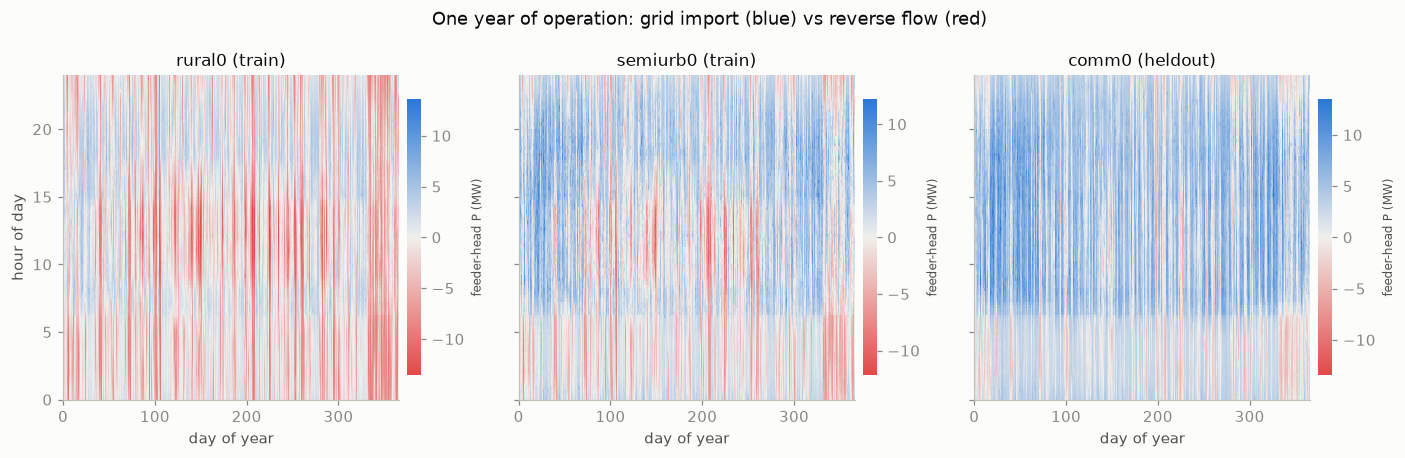

reverse-flow share of the year: {'rural0': '55.6%', 'semiurb0': '33.1%', 'comm0': '14.5%'}


In [2]:
# fig01 — the year at a glance: feeder-head active power, day × time-of-day.
# Signed quantity (import > 0, reverse flow < 0) → diverging blue↔red, gray midpoint.
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

div = LinearSegmentedColormap.from_list("div", [C["red"], "#f0efec", C["blue"]])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, f in zip(axes, FEEDERS):
    head = D[f]["dyn"][:, D[f]["ref"], 2]            # Pg at REF = grid import (MW)
    days = head.reshape(-1, 96)
    lim = np.abs(days).max()
    im = ax.imshow(days.T, aspect="auto", origin="lower", cmap=div,
                   norm=TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim),
                   extent=[0, days.shape[0], 0, 24], interpolation="nearest")
    ax.set_title(f"{f} ({D[f]['meta']['role']})", fontsize=11)
    ax.set_xlabel("day of year")
    ax.grid(False)
    cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label("feeder-head P (MW)", fontsize=8)
    cb.outline.set_visible(False)
axes[0].set_ylabel("hour of day")
fig.suptitle("One year of operation: grid import (blue) vs reverse flow (red)",
             fontsize=12, color=INK)
fig.tight_layout()
fig.savefig(RES / "fig01_year_heatmap.png", bbox_inches="tight")
plt.show()

rev = {f: float((D[f]["dyn"][:, D[f]["ref"], 2] < 0).mean()) for f in FEEDERS}
print("reverse-flow share of the year:", {k: f"{v:.1%}" for k, v in rev.items()})

**Reading fig01 (power terms).** The x-axis walks through the year, the y-axis
through the day. First honest surprise of M1: reverse flow is **wind-driven, not
PV-driven**. The MV-level DER on these feeders is dominated by wind (rural0: 11.4 MW
wind vs 0.3 MW MV-PV, plus 12.5 MW aggregated LV renewables; similar mixes on the other
two — read from the sgen tables), so the red regions come as **day-long vertical
stripes** (windy days, any season, any hour) and a **pre-dawn band** (night wind against
minimum load), with LV-PV adding midday structure on top. A clean seasonal left-right
gradient is *not* visible at the feeder head — weather, not season, sets the export
regime. The modeling lesson survives and sharpens: the same hours go red simultaneously
across the feeder because one weather field drives every unit — exactly the cross-unit
correlation an independent per-node sampler cannot produce, and now with two drivers
(wind field + sun) on different schedules.

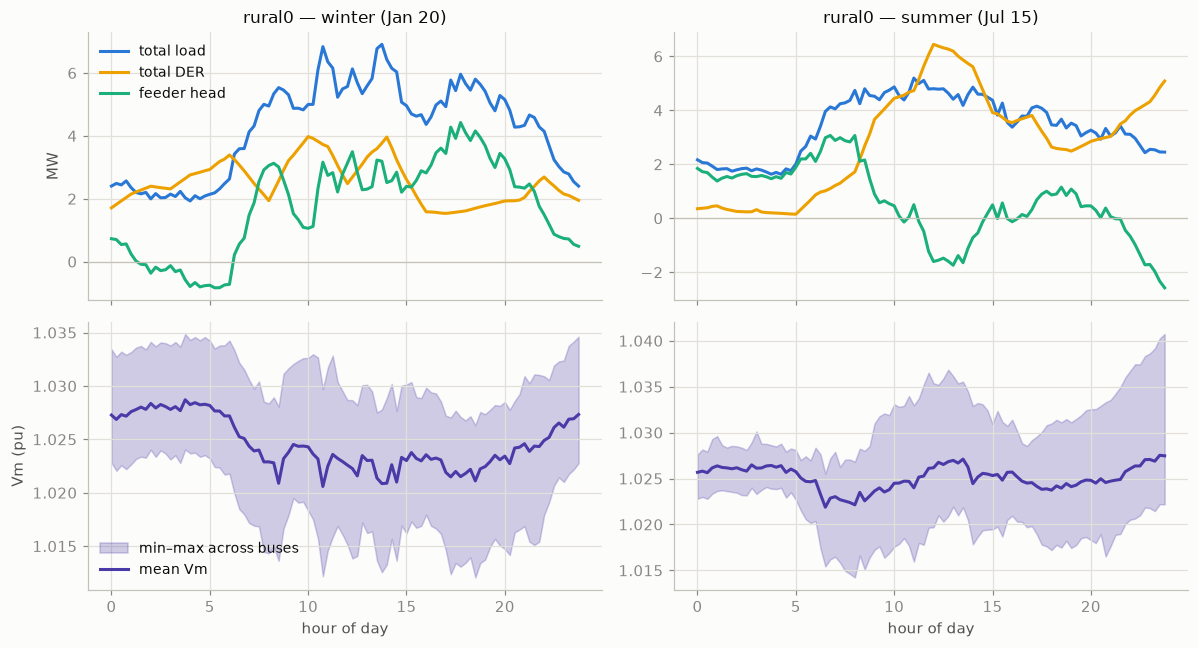

In [3]:
# fig02 — two days in full: winter working day vs summer day (train feeder rural0).
f = "rural0"
dyn, ref = D[f]["dyn"], D[f]["ref"]
tot_load = dyn[:, :, 0].sum(axis=1)
head = dyn[:, ref, 2]
der = dyn[:, :, 2].sum(axis=1) - head                # all Pg minus slack = DER output
days = {"winter (Jan 20)": 19, "summer (Jul 15)": 196}
hours = np.arange(96) / 4

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for col, (label, d) in enumerate(days.items()):
    s = slice(d * 96, (d + 1) * 96)
    ax = axes[0, col]
    ax.plot(hours, tot_load[s], color=C["blue"], lw=2, label="total load")
    ax.plot(hours, der[s], color=C["yellow"], lw=2, label="total DER")
    ax.plot(hours, head[s], color=C["aqua"], lw=2, label="feeder head")
    ax.axhline(0, color="#c3c2b7", lw=0.8)
    ax.set_title(f"{f} — {label}", fontsize=11)
    if col == 0:
        ax.set_ylabel("MW")
        ax.legend(frameon=False, fontsize=9)
    vm = dyn[s, :, 4]
    ax = axes[1, col]
    ax.fill_between(hours, vm.min(axis=1), vm.max(axis=1), color=C["violet"], alpha=0.25,
                    label="min–max across buses")
    ax.plot(hours, vm.mean(axis=1), color=C["violet"], lw=2, label="mean Vm")
    ax.set_xlabel("hour of day")
    if col == 0:
        ax.set_ylabel("Vm (pu)")
        ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(RES / "fig02_two_days.png", bbox_inches="tight")
plt.show()

**Reading fig02.** Winter day: the feeder exports **pre-dawn** (wind against 2 MW
night load), then imports through the working day as load dominates. Summer day: DER
peaks past 6 MW around noon (LV-PV on top of wind) pushing the head negative, and rises
again in the evening — wind doesn't keep office hours. The voltage panel: the whole
feeder sits *above* nominal (≈1.015–1.04 pu — substation setpoint/tap), and the upper
edge of the min–max band pushes highest exactly during export periods (summer midday,
late evening) — the voltage-**rise**-under-reverse-flow signature of a high-R/X feeder.
That coupling is what a statistically-plausible-but-physics-free generator gets wrong:
nothing in the statistics alone forbids heavy export with *falling* voltage, but
Kirchhoff on this R/X does.

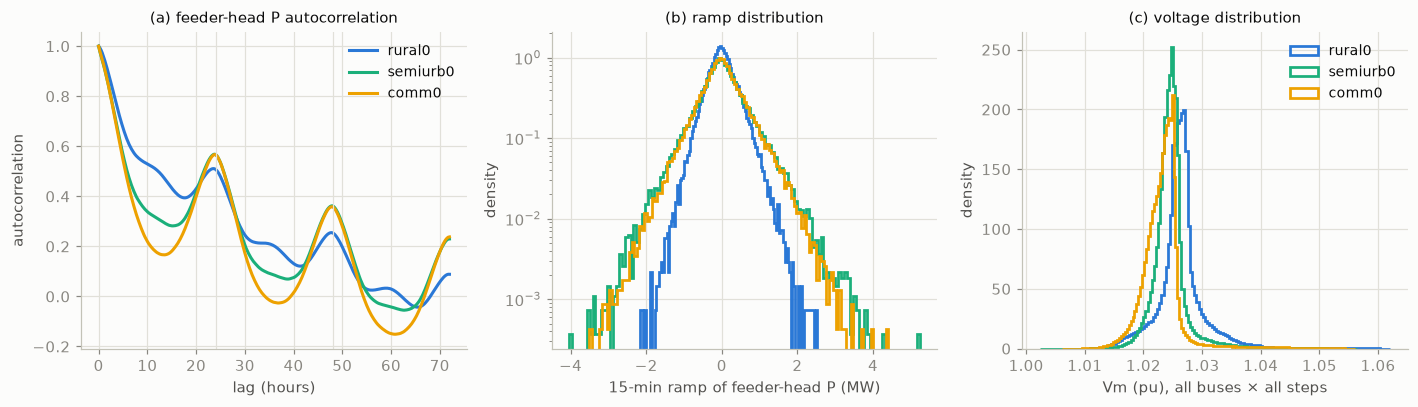

,feeder,reverse_flow_pct,vm_min,vm_max,peak_import_MW,peak_export_MW,peak_total_load_MW,peak_total_DER_MW
0,rural0,55.6,1.0063,1.0621,6.37,13.57,7.51,18.41
1,semiurb0,33.1,1.0023,1.0564,12.18,10.59,13.40,16.56
2,comm0,14.5,1.0062,1.0561,13.46,6.52,14.94,12.15


In [4]:
# fig03 — the statistical fingerprints the generator must match.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]                                          # (a) autocorrelation, 3 days
for f in FEEDERS:
    x = D[f]["dyn"][:, D[f]["ref"], 2]
    x = (x - x.mean()) / x.std()
    n = len(x)
    lags = np.arange(0, 96 * 3 + 1)
    ac = [1.0] + [float(np.dot(x[:-l], x[l:]) / (n - l)) for l in lags[1:]]
    ax.plot(lags / 4, ac, color=FCOLOR[f], lw=2, label=f)
ax.axvline(24, color=GRID, lw=0.8)
ax.axvline(48, color=GRID, lw=0.8)
ax.set_xlabel("lag (hours)"); ax.set_ylabel("autocorrelation")
ax.set_title("(a) feeder-head P autocorrelation", fontsize=10)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]                                          # (b) 15-min ramps
for f in FEEDERS:
    head = D[f]["dyn"][:, D[f]["ref"], 2]
    ramps = np.diff(head)
    ax.hist(ramps, bins=120, density=True, histtype="step", lw=1.8, color=FCOLOR[f])
ax.set_yscale("log")
ax.set_xlabel("15-min ramp of feeder-head P (MW)"); ax.set_ylabel("density")
ax.set_title("(b) ramp distribution", fontsize=10)

ax = axes[2]                                          # (c) voltage magnitudes
for f in FEEDERS:
    vm = D[f]["dyn"][:, :, 4].ravel()
    ax.hist(vm, bins=150, density=True, histtype="step", lw=1.8, color=FCOLOR[f], label=f)
ax.set_xlabel("Vm (pu), all buses × all steps"); ax.set_ylabel("density")
ax.set_title("(c) voltage distribution", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(RES / "fig03_fingerprints.png", bbox_inches="tight")
plt.show()

summary = pd.DataFrame([{
    "feeder": f,
    "reverse_flow_pct": round(100 * float((D[f]["dyn"][:, D[f]["ref"], 2] < 0).mean()), 1),
    "vm_min": round(float(D[f]["dyn"][:, :, 4].min()), 4),
    "vm_max": round(float(D[f]["dyn"][:, :, 4].max()), 4),
    "peak_import_MW": round(float(D[f]["dyn"][:, D[f]["ref"], 2].max()), 2),
    "peak_export_MW": round(-float(D[f]["dyn"][:, D[f]["ref"], 2].min()), 2),
    "peak_total_load_MW": round(float(D[f]["dyn"][:, :, 0].sum(axis=1).max()), 2),
    "peak_total_DER_MW": round(float((D[f]["dyn"][:, :, 2].sum(axis=1)
                                      - D[f]["dyn"][:, D[f]["ref"], 2]).max()), 2),
} for f in FEEDERS])
summary.to_csv(RES / "m1_dataset_summary.csv", index=False)
summary

**Reading fig03.** (a) Clear 24 h / 48 h autocorrelation peaks — the daily rhythm —
riding on a decaying weather envelope; rural0 decays slowest at short lags (wind
persistence dominates its head flow). These are Cramer-validation metrics the generated
samples must reproduce. (b) Ramps are heavy-tailed on all feeders — multi-MW 15-min
jumps from wind fronts and evening pickup that a Gaussian sampler underestimates badly;
note rural0 is the *narrowest* (its bigger LV-RES share aggregates more smoothly), so
tail weight is a feeder fingerprint, not a constant. (c) Voltages live at 1.00–1.06 pu —
above nominal by substation setpoint — with rural0 shifted highest and widest (longest
lines, DER 2.7× peak load). These panels, plus fig01's cross-unit correlation, are the
fidelity axes of the M2 evaluation.

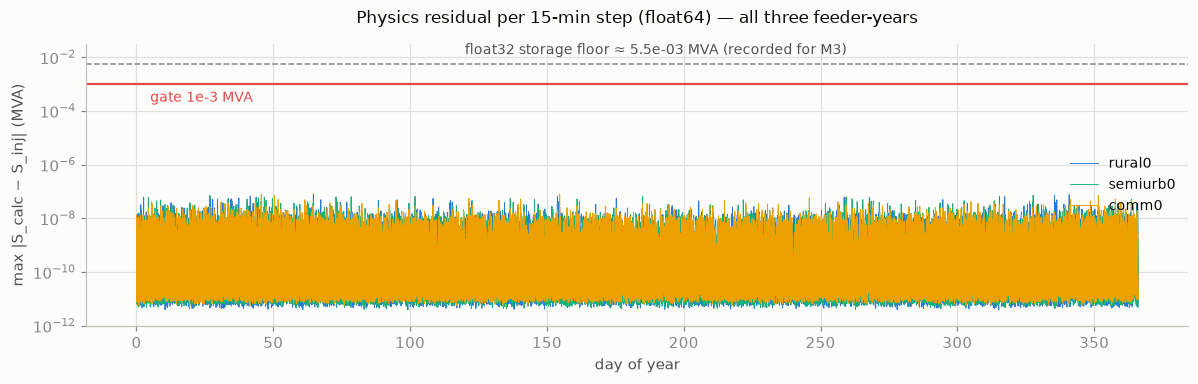

In [5]:
# fig04 — the physics self-check, every step of every feeder-year.
fig, ax = plt.subplots(figsize=(11, 3.6))
for f in FEEDERS:
    ax.plot(np.arange(len(D[f]["resid"])) / 96, D[f]["resid"], lw=0.6,
            color=FCOLOR[f], label=f)
ax.axhline(1e-3, color=C["red"], lw=1.4)
ax.annotate("gate 1e-3 MVA", xy=(5, 1e-3), xytext=(5, 2.2e-4),
            color=C["red"], fontsize=9)
fl = np.mean([D[f]["meta"]["resid_float32_floor_mva"] for f in FEEDERS])
ax.axhline(fl, color=MUTED, lw=1.0, ls="--")
ax.annotate(f"float32 storage floor ≈ {fl:.1e} MVA (recorded for M3)",
            xy=(5, fl), xytext=(120, 1.3e-2), color=INK2, fontsize=9)
ax.set_yscale("log")
ax.set_ylim(1e-12, 3e-2)
ax.set_xlabel("day of year"); ax.set_ylabel("max |S_calc − S_inj| (MVA)")
ax.set_title("Physics residual per 15-min step (float64) — all three feeder-years",
             fontsize=11, pad=14)
ax.legend(frameon=False, fontsize=9, loc="center right")
fig.tight_layout()
fig.savefig(RES / "fig04_physics_gate.png", bbox_inches="tight")
plt.show()

**Reading fig04.** Every one of the 105,408 solved states sits orders of magnitude
below the 1e-3 MVA gate — the labels the generator will learn from are exact power-flow
solutions, so any physics violation measured on *generated* samples in M3 is the
model's, not the dataset's. The dashed line is the float32 casting floor: the honest
reference point for GPU-tensor residuals later.

## M1 assumptions (logged)

1. **Profiles are the scenario sequence** — SimBench study year (366 days, 15 min); no
   random sampling, so the dataset is deterministic and regenerates exactly.
2. **Base topology only.** Reconfiguration variants are deferred to M5 (transfer demo);
   M1 trains the generator on the feeders as built.
3. **No storage on the three chosen feeders** (verified) — the companion study's storage-folding
   logic is inherited but inactive.
4. **sgen Q follows SimBench defaults** (unity power factor where the dataset says so);
   DER reactive control strategies are out of scope.
5. **float64 storage** of the year arrays; the measured float32 floor (~3e-3 MVA) is
   carried in each file's meta for M3.